<a href="https://colab.research.google.com/github/maumandisaya/Job-Classification/blob/main/Job_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.5 MB/s eta 0:00:00


In [2]:
pip install imbalanced-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from category_encoders.binary import BinaryEncoder
from collections import Counter
from imblearn.over_sampling import SMOTENC

## Load Dataset dan Analisis Data Eksploratif

In [5]:
# Run this line again if error
# Kasih try-except untuk mencegah error terjadi dan eksekusi menjadi terhambat

file_path = kagglehub.dataset_download('lastman0800/job-recomendation-dataset')
df = pd.read_csv("/kaggle/input/job-recomendation-dataset/Job Datsset.csv")

Using Colab cache for faster access to the 'job-recomendation-dataset' dataset.


In [31]:
# Copy data asli
df_copy = df.copy()
df_copy.tail()

,User_ID,Job_ID,User_Skills,Job_Requirements,Match_Score,Recommended
99995,99996,380,"C++, Machine Learning, SQL","Machine Learning, C++, CSS, SQL, HTML",0.537153,0
99996,99997,402,"C++, SQL, HTML, Python, JavaScript","Data Science, AI, JavaScript",0.319933,0
99997,99998,212,"Data Science, C++","C++, Java",0.292062,0
99998,99999,40,"Python, HTML, AI","AI, CSS, Python, C++, JavaScript",0.450705,0
99999,100000,437,"C++, JavaScript, HTML, Java, SQL","Python, Machine Learning, Data Science",0.630679,0


In [15]:
print(f'Jumlah data yang duplikat : {df.duplicated().sum()}\n')
print(f'Jumlah missing value pada setiap kolom \n{df.isnull().sum()}\n')
print(f'Jumlah Kategori pada \'User_Skills\' : {len(df_copy['User_Skills'].unique())}\n')
print(f'Jumlah Kategori pada \'Job_Requirements\' : {len(df_copy['Job_Requirements'].unique())}\n')

Jumlah data yang duplikat : 0

Jumlah missing value pada setiap kolom 
User_ID             0
Job_ID              0
User_Skills         0
Job_Requirements    0
Match_Score         0
Recommended         0
dtype: int64

Jumlah Kategori pada 'User_Skills' : 22869

Jumlah Kategori pada 'Job_Requirements' : 22708



In [16]:
# Melakukan cleaning dengan menghilangkan whitespace, lower case semua huruf

Job_Requirements_stripped = df_copy['Job_Requirements'].str.replace(' ','')
User_Skills_stripped= df_copy['User_Skills'].str.replace(' ','')

Job_Requirements_lowercase = Job_Requirements_stripped.str.lower()
User_Skills_lowercase = User_Skills_stripped.str.lower()

Job_Requirements_splitted =Job_Requirements_lowercase.str.split(',')
User_Skills_splitted = User_Skills_lowercase.str.split(',')

In [17]:
df_copy['Job_Requirements'] = Job_Requirements_splitted
df_copy['User_Skills'] = User_Skills_splitted

In [18]:
df_copy.head()

,User_ID,Job_ID,User_Skills,Job_Requirements,Match_Score,Recommended
0,1,16,"[python, c++, machinelearning]","[sql, css, ai, javascript, datascience]",0.620421,0
1,2,30,"[ai, python, datascience]","[ai, datascience, sql, python, css]",0.823451,1
2,3,319,"[css, python, machinelearning]","[sql, ai, python]",0.703830,0
3,4,399,"[sql, machinelearning, c++]","[java, ai, python, datascience, machinelearning]",0.224724,0
4,5,405,"[machinelearning, html, javascript]","[machinelearning, c++]",0.296453,0


In [19]:
'''Membuat Loop untuk mengurutkan entri pada kolom User_Skills dan Job_Requirements'''
try :
  for row in range(len(df)) :
    df_copy.loc[row,'User_Skills'].sort()
    df_copy.loc[row,'Job_Requirements'].sort()
  df_copy.head()
except Exception as e:
  print('Ada yang salah, silahkan coba lagi')
  raise

In [20]:
df_copy.sort_values(by= 'User_Skills').head()

,User_ID,Job_ID,User_Skills,Job_Requirements,Match_Score,Recommended
41010,41011,207,"[ai, c++]","[ai, datascience, java, python]",0.882206,1
51392,51393,267,"[ai, c++]","[datascience, html, java]",0.368673,0
71572,71573,55,"[ai, c++]","[css, html, python]",0.232805,0
20268,20269,257,"[ai, c++]","[machinelearning, sql]",0.080154,0
20595,20596,109,"[ai, c++]","[ai, c++, datascience, java, machinelearning]",0.119723,0


In [21]:
df_sorted = df.copy()

In [22]:
df_sorted['User_Skills'] = df_copy['User_Skills'].str.join(',')
df_sorted['Job_Requirements'] = df_copy['Job_Requirements'].str.join(',')

In [ ]:
df_sorted.head()

,User_ID,Job_ID,User_Skills,Job_Requirements,Match_Score,Recommended
0,1,16,"c++,machinelearning,python","ai,css,datascience,javascript,sql",0.620421,0
1,2,30,"ai,datascience,python","ai,css,datascience,python,sql",0.823451,1
2,3,319,"css,machinelearning,python","ai,python,sql",0.703830,0
3,4,399,"c++,machinelearning,sql","ai,datascience,java,machinelearning,python",0.224724,0
4,5,405,"html,javascript,machinelearning","c++,machinelearning",0.296453,0


In [23]:
df_sorted.drop(['User_ID','Job_ID'], axis = 1, inplace = True)

In [24]:
df_sorted.tail()

,User_Skills,Job_Requirements,Match_Score,Recommended
99995,"c++,machinelearning,sql","c++,css,html,machinelearning,sql",0.537153,0
99996,"c++,html,javascript,python,sql","ai,datascience,javascript",0.319933,0
99997,"c++,datascience","c++,java",0.292062,0
99998,"ai,html,python","ai,c++,css,javascript,python",0.450705,0
99999,"c++,html,java,javascript,sql","datascience,machinelearning,python",0.630679,0


In [25]:
# Cek kardinalitas pada variabel kategorikal

print(f'Jumlah Kategori pada \'User_Skills\' setelah preprocessing : {len(df_sorted['User_Skills'].unique())}\n')
print(f'Jumlah Kategori pada \'Job_Requirements\' : {len(df_sorted['Job_Requirements'].unique())}\n')

Jumlah Kategori pada 'User_Skills' setelah preprocessing : 627

Jumlah Kategori pada 'Job_Requirements' : 627



In [26]:
'''Meng-check komposisi target'''
hitung_komposisi = Counter(df_sorted['Recommended'])
print(f'Komposisi target :\n{hitung_komposisi}')

Komposisi target :
Counter({0: 80073, 1: 19927})


In [27]:
df_final = df_sorted.copy()

**DataFrame yang telah dibuat**

1. df : Dataframe asli
2. df_copy : Dataframe copy yang digunakan untuk menyimpan entri kolom user_skills dan job_requirements menjadi terurut, lowercase, dan menghilangkan whitepace (masih dalam bentuk list)
3. df_sorted : dataframe terurut dengan variabel kategori berformat string
4. df_final : dataframe yang siap digunakan untuk training dan test model


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from category_encoders.binary import BinaryEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split

X = df_final.drop('Recommended', axis = 1)
y = df_final['Recommended']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size = 0.3)

columns_transformer = ColumnTransformer(
    [('biner_encoder', BinaryEncoder(),['User_Skills','Job_Requirements']),
     ('std_scaler', StandardScaler(), ['Match_Score'])],
     remainder='passthrough')

model = Pipeline(steps=[("prepro", columns_transformer),('random_forest',RandomForestClassifier(random_state = 42, class_weight='balanced'))])

tuning = {'random_forest__n_estimators':[100,150,200],
          'random_forest__max_depth': [5,6,7,8,9,10],
          'random_forest__min_samples_leaf' : [2,3,4,5,6]}

random_search = RandomizedSearchCV(model, tuning, cv = 5, n_iter=50)
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prepro',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('biner_encoder',
                                                                               BinaryEncoder(),
                                                                               ['User_Skills',
                                                                                'Job_Requirements']),
                                                                              ('std_scaler',
                                                                               StandardScaler(),
                                                                               ['Match_Score'])])),
                                             ('random_forest',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_iter=50,
                   param_distributions={'random_forest__max_depth': [5, 6, 7, 8,
                                                                     9, 10],
                                        'random_forest__min_samples_leaf': [2,
                                                                            3,
                                                                            4,
                                                                            5,
                                                                            6],
                                        'random_forest__n_estimators': [100,
                                                                        150,
                                                                        200]})

In [ ]:
# Set parameter terbaik pada model
best_params = random_search.best_params_
model.set_params(**best_params)

# Fit model kemudian test menggunakan data test
model.fit(X_train, y_train)
y_predict_test = model.predict(X_test)

In [ ]:
print(best_params)

{'random_forest__n_estimators': 200, 'random_forest__min_samples_leaf': 6, 'random_forest__max_depth': 7}


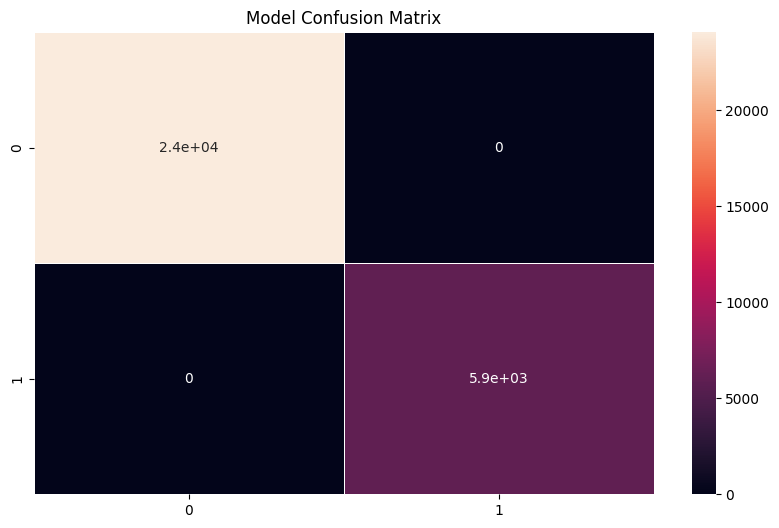

1.0


In [ ]:
# Lakukan Evaluasi menggunakan confusion matrix dan F1-Score
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cf = confusion_matrix(y_test, y_predict_test)
plt.figure(figsize= (10,6))
sns.heatmap(cf,annot= True, linewidths=0.5)
plt.title('Model Confusion Matrix')
plt.show()

print(f1_score(y_test,y_predict_test))

In [ ]:
# Export Model yang sudah di train dan test ke dalam format pkl
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']

In [32]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

# Define the packages used in this notebook that should be in requirements.txt
required_packages = [
    'pandas',
    'scikit-learn',
    'matplotlib',
    'category_encoders'
]

# Create requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        # Fallback if package is not found for some reason, though it should be if used
        requirements_content.append(f"{pkg}")

# Write to requirements.txt file
with open('requirements.txt', 'w') as f:
    for item in requirements_content:
        f.write(f"{item}\n")

print("requirements.txt created successfully.")

/tmp/ipykernel_3414/1390639714.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


requirements.txt created successfully.
